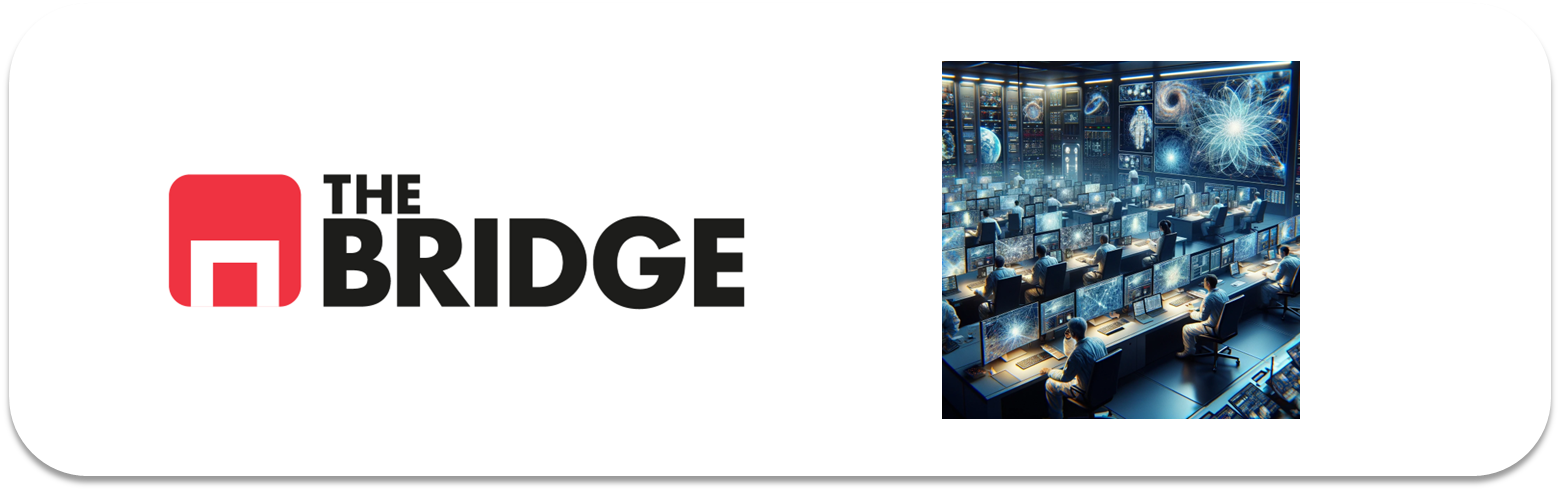

## PRACTICA OBLIGATORIA: **Transfer Learning y Fine Tuning con CNN**

* La práctica obligatoria de esta unidad consiste en un repetir el ejercicio de construcción de un modelo de clasificación de paisajes pero usando un modelo preentrenado. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

### Objetivo del ejercicio

Comparar una red convolucional hecha ad-hoc frente a los modelos preentrenados y ajustados con fine tuning y transfer learning. Para ello emplea el dataset de paisajes del conjunto de ejercicios de la unidad anterior.


### Se pide

1. Preparar los datos del modelo y las funciones de visualización, copia para ello todo lo que necesites de las soluciones del ejercicio de clasificación de paisajes de la unidad anterior.

2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.

4. Hacer un transfer-learning con una cabeza de como mucho 2 capas densas ocultas y una de salida. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

5. Hacer un fine-tuning con la misma cabeza diseñada en el punto anterior. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

6. Comparar los resultados con los obtenidos con la red convolucional del ejercicio mencionado.

EXTRA:
- Repetir el transfer learning empleando aumentado de imágenes.



### Ejercicio 0

In [50]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import imageio.v3 as iio

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

### Ejercicio 1

DataFrame con nombres de archivo y categorías (cat / dog). Dividimos en train (64%), validate (16%) y test (20%).

In [51]:
IM_SIZE = 96
DATA_DIR = './data/'

# Recopilamos imágenes de todos los subdirectorios
filenames, categories = [], []
for subdir in sorted(d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))):
    for fname in os.listdir(os.path.join(DATA_DIR, subdir)):
        filenames.append(os.path.join(subdir, fname))
        categories.append(fname.split('.')[0])   # 'cat' o 'dog'

df = pd.DataFrame({'filename': filenames, 'category': categories})
print("Total imágenes:", len(df))
print(df['category'].value_counts())

train_df, test_df   = train_test_split(df, test_size=0.20, random_state=42, stratify=df['category'])
train_df, val_df    = train_test_split(train_df, test_size=0.20, random_state=42, stratify=train_df['category'])

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Total imágenes: 4000
category
cat    2000
dog    2000
Name: count, dtype: int64

Train: 2560 | Val: 640 | Test: 800


### Visualización de los datos

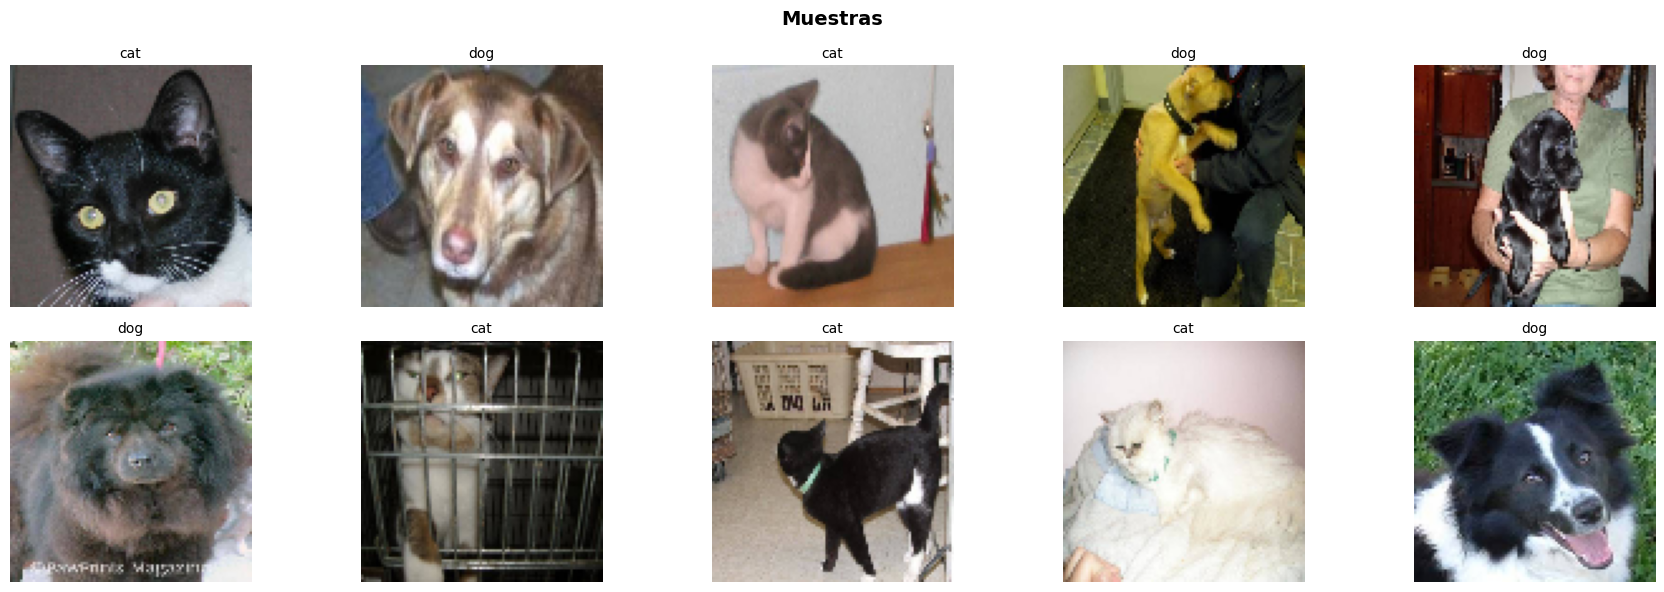

In [52]:
def load_image(path, im_size=IM_SIZE):
    img = iio.imread(path)
    if img.ndim == 2:
        img = np.stack([img]*3, axis=-1)
    elif img.shape[2] == 4:
        img = img[:, :, :3]
    return cv2.resize(img, (im_size, im_size))

def plot_samples(df, base_path, n=10, title="Muestras"):
    sample = df.sample(n, random_state=1).reset_index(drop=True)
    fig, axes = plt.subplots(2, n//2, figsize=(18, 6))
    axes = axes.flatten()
    for i, row in sample.iterrows():
        img = load_image(os.path.join(base_path, row['filename']))
        axes[i].imshow(img)
        axes[i].set_title(row['category'], fontsize=10)
        axes[i].axis('off')
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_samples(train_df, DATA_DIR, n=10, title="Muestras")

### Mini EDA

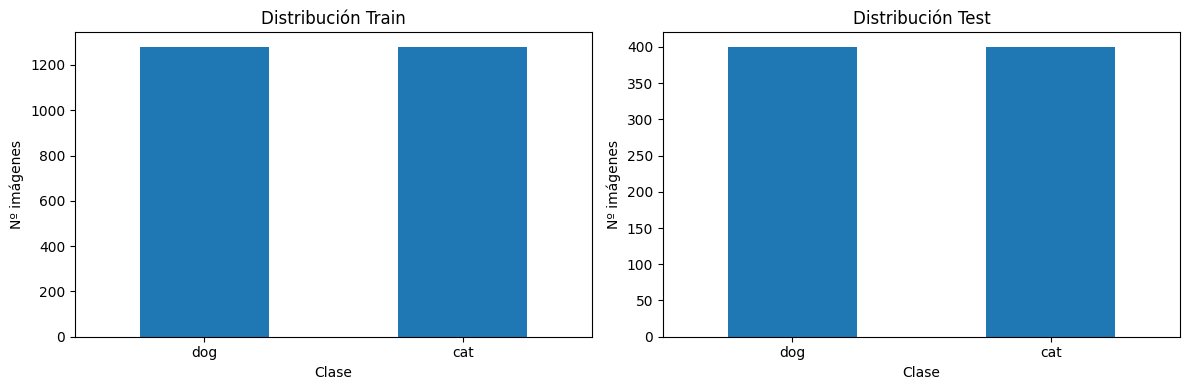

Las clases están balanceadas y se usara accuracy como métrica principal.


In [53]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (split_name, split_df) in zip(axes, [('Train', train_df), ('Test', test_df)]):
    split_df['category'].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(f'Distribución {split_name}')
    ax.set_xlabel('Clase')
    ax.set_ylabel('Nº imágenes')
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print("Las clases están balanceadas y se usara accuracy como métrica principal.")

### Cargar imágenes

In [54]:
def df_to_arrays(df, base_path, im_size=IM_SIZE, normalize=True):
    X, y = [], []
    for _, row in df.iterrows():
        img = load_image(os.path.join(base_path, row['filename']), im_size)
        X.append(img / 255. if normalize else img)
        y.append(1 if row['category'] == 'dog' else 0)
    return np.array(X, dtype=np.float32), np.array(y)

X_train, y_train = df_to_arrays(train_df, DATA_DIR)
X_val,   y_val   = df_to_arrays(val_df,   DATA_DIR)
X_test,  y_test  = df_to_arrays(test_df,  DATA_DIR)

X_train, y_train = shuffle(X_train, y_train, random_state=42)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}  y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}  y_test:  {y_test.shape}")

X_train: (2560, 96, 96, 3)  y_train: (2560,)
X_val:   (640, 96, 96, 3)  y_val:   (640,)
X_test:  (800, 96, 96, 3)  y_test:  (800,)


### Función de evaluación

In [55]:
CLASS_NAMES = ['cat', 'dog']

def evaluate_model(model, X_test, y_test, model_name="Modelo"):
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"  {model_name}")
    print(f"  Test Loss:     {loss:.4f}")
    print(f"  Test Accuracy: {acc:.4f} ({acc*100:.1f}%)")
    
    y_pred = (model.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
    print("\n--- Classification Report ---")
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax)
    ax.set_title(f'Matriz de Confusión — {model_name}')
    plt.tight_layout()
    plt.show()
    
    return loss, acc

def plot_history(history, title="Entrenamiento"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, metric, ylabel in zip(axes, ['loss', 'accuracy'], ['Pérdida', 'Accuracy']):
        val_key = f'val_{metric}'
        if metric not in history.history:
            metric = 'acc'
        if val_key not in history.history:
            val_key = 'val_acc'
        ax.plot(history.history[metric],label='Train',linewidth=2)
        ax.plot(history.history[val_key],label='Validation')
        ax.set_title(f'{ylabel} — {title}')
        ax.set_xlabel('Época')
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Baseline — CNN entrenada desde cero

Antes de aplicar Transfer Learning, construimos una CNN sencilla ad-hoc para tener una referencia de comparación.

In [56]:
def build_baseline_cnn(input_shape=(IM_SIZE, IM_SIZE, 3)):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ], name='CNN_Baseline')
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

cnn_baseline = build_baseline_cnn()
cnn_baseline.summary()

Model: "CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,813,249 (18.36 MB)

 Trainable params: 4,812,801 (18.36 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.6020 - loss: 1.8400 - val_accuracy: 0.5000 - val_loss: 3.4274
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.6633 - loss: 0.6348 - val_accuracy: 0.5531 - val_loss: 0.8781
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - accuracy: 0.7031 - loss: 0.5716 - val_accuracy: 0.6047 - val_loss: 0.8680
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - accuracy: 0.7402 - loss: 0.5321 - val_accuracy: 0.6156 - val_loss: 0.6478
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - accuracy: 0.7727 - loss: 0.4903 - val_accuracy: 0.6500 - val_loss: 0.6518
Epoch 6/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.8008 - loss: 0.4270 - val_accuracy: 0.6812 - val_loss: 0.6960
Epoch 7/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - accuracy: 0.8152 - loss: 0.4039 - val_accuracy: 0.6953 - val_loss: 0.7074
Epoch 8/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - accuracy: 0.8457 - loss: 0.3474 - val_accuracy: 0.7172 - v

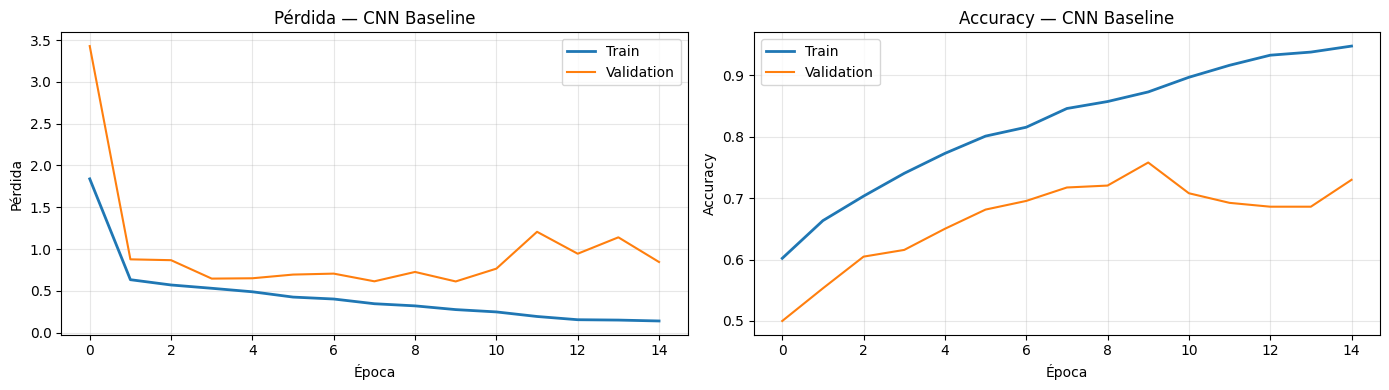

In [57]:
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1)

history_baseline = cnn_baseline.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=32,
    epochs=30,
    callbacks=[early_stop],
    verbose=1
)

plot_history(history_baseline, title="CNN Baseline")

  CNN Baseline (ad-hoc)
  Test Loss:     0.6419
  Test Accuracy: 0.7600 (76.0%)

--- Classification Report ---
              precision    recall  f1-score   support

         cat       0.76      0.76      0.76       400
         dog       0.76      0.76      0.76       400

    accuracy                           0.76       800
   macro avg       0.76      0.76      0.76       800
weighted avg       0.76      0.76      0.76       800



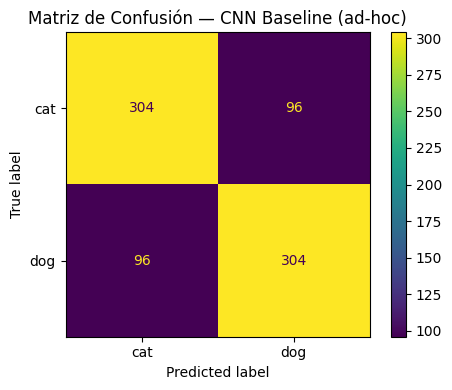

In [58]:
loss_base, acc_base = evaluate_model(cnn_baseline, X_test, y_test, "CNN Baseline (ad-hoc)")


## Ejercicio 2 y 3 - Transfer Learning con MobileNetV2

Descargamos MobileNetV2 preentrenado con ImageNet, congelamos todas sus capas y añadimos nuestra propia cabeza densa para clasificación binaria.

#### Elegimos MobileNetV2 ya que es lo que se recomienda el enunciado

In [59]:
def build_transfer_model(input_shape=(IM_SIZE, IM_SIZE, 3), trainable_base=False):
    base = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet' if not trainable_base else None
    )
    base.trainable = trainable_base
    
    # Cabeza personalizada (máx. 2 capas ocultas según el enunciado)
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)   # Más eficiente que Flatten para MobileNetV2
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(1, activation='sigmoid')(x)
    
    model = tf.keras.Model(inputs=base.input, outputs=x,
                           name='TransferLearning' if not trainable_base else 'FineTuning')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

tl_model = build_transfer_model(trainable_base=False)
tl_model.summary()

Model: "TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_7[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,914,369 (11.12 MB)

 Trainable params: 656,385 (2.50 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

#### Aumento de imágenes para Transfer Learning

In [60]:
# Generadores con aumentado de datos
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen_tl = train_datagen.flow_from_dataframe(
    train_df, DATA_DIR, x_col='filename', y_col='category',
    target_size=(IM_SIZE, IM_SIZE), batch_size=32, class_mode='binary'
)
val_gen_tl = val_datagen.flow_from_dataframe(
    val_df, DATA_DIR, x_col='filename', y_col='category',
    target_size=(IM_SIZE, IM_SIZE), batch_size=32, class_mode='binary'
)
test_gen_tl = val_datagen.flow_from_dataframe(
    test_df, DATA_DIR, x_col='filename', y_col='category',
    target_size=(IM_SIZE, IM_SIZE), batch_size=32, class_mode='binary', shuffle=False
)

Found 2560 validated image filenames belonging to 2 classes.


Found 640 validated image filenames belonging to 2 classes.
Found 800 validated image filenames belonging to 2 classes.


Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - accuracy: 0.8313 - loss: 0.3800 - val_accuracy: 0.9297 - val_loss: 0.1680
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9047 - loss: 0.2262 - val_accuracy: 0.9234 - val_loss: 0.1593
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9156 - loss: 0.2043 - val_accuracy: 0.9266 - val_loss: 0.1531
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9273 - loss: 0.1781 - val_accuracy: 0.9375 - val_loss: 0.1477
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9246 - loss: 0.1756 - val_accuracy: 0.9250 - val_loss: 0.1707
Epoch 6/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9281 - loss: 0.1727 - val_accuracy: 0.9438 - val_loss: 0.1412
Epoch 7/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9301 - loss: 0.1682 - val_accuracy: 0.9359 - val_loss: 0.1454
Epoch 8/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9430 - loss: 0.1495 - val_accuracy: 0.9438 - v

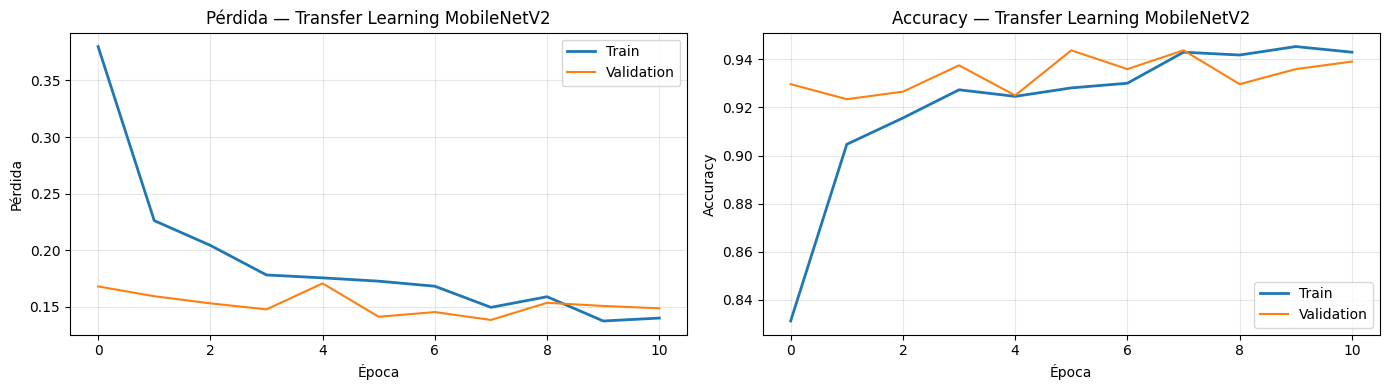

In [61]:
early_stop_tl = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1)

history_tl = tl_model.fit(
    train_gen_tl,
    validation_data=val_gen_tl,
    epochs=20,
    callbacks=[early_stop_tl],
    verbose=1
)

plot_history(history_tl, title="Transfer Learning MobileNetV2")

Transfer Learning / Loss: 0.1291 | Accuracy: 0.9438
              precision    recall  f1-score   support

         cat       0.95      0.94      0.94       400
         dog       0.94      0.95      0.94       400

    accuracy                           0.94       800
   macro avg       0.94      0.94      0.94       800
weighted avg       0.94      0.94      0.94       800



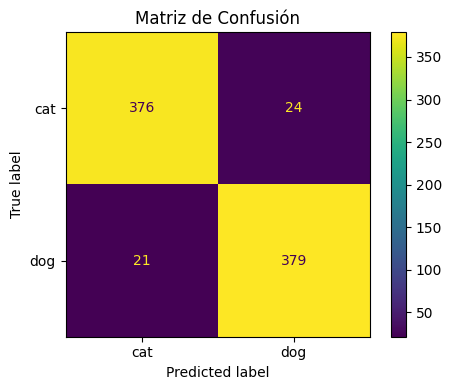

In [62]:
loss_tl = tl_model.evaluate(test_gen_tl, verbose=0)
print(f"Transfer Learning / Loss: {loss_tl[0]:.4f} | Accuracy: {loss_tl[1]:.4f}")

y_pred_tl = (tl_model.predict(test_gen_tl, verbose=0) > 0.5).astype(int).flatten()
y_true_tl = test_gen_tl.labels

print(classification_report(y_true_tl, y_pred_tl, target_names=CLASS_NAMES))

cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tl, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax)
ax.set_title('Matriz de Confusión')
plt.tight_layout()
plt.show()

acc_tl = loss_tl[1]


## Ejercicio 4 - Fine-Tuning con MobileNetV2

Cargamos la misma arquitectura sin pesos preentrenados y entrenamos toda la red desde cero.

In [63]:
ft_model = build_transfer_model(trainable_base=True)
ft_model.summary()

Model: "FineTuning"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_8[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,914,369 (11.12 MB)

 Trainable params: 2,880,257 (10.99 MB)

 Non-trainable params: 34,112 (133.25 KB)

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 25s 144ms/step - accuracy: 0.5262 - loss: 0.7350 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 141ms/step - accuracy: 0.5863 - loss: 0.6780 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 148ms/step - accuracy: 0.6207 - loss: 0.6521 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 145ms/step - accuracy: 0.6527 - loss: 0.6229 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 147ms/step - accuracy: 0.7004 - loss: 0.5731 - val_accuracy: 0.5000 - val_loss: 0.6936
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 147ms/step - accuracy: 0.7371 - loss: 0.5211 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 147ms/step - accuracy: 0.7508 - loss: 0.4951 - val_accuracy: 0.5000 - val_loss: 0.6936
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 150ms/step - accuracy: 0.8094 - loss: 0.4039 - val_accu

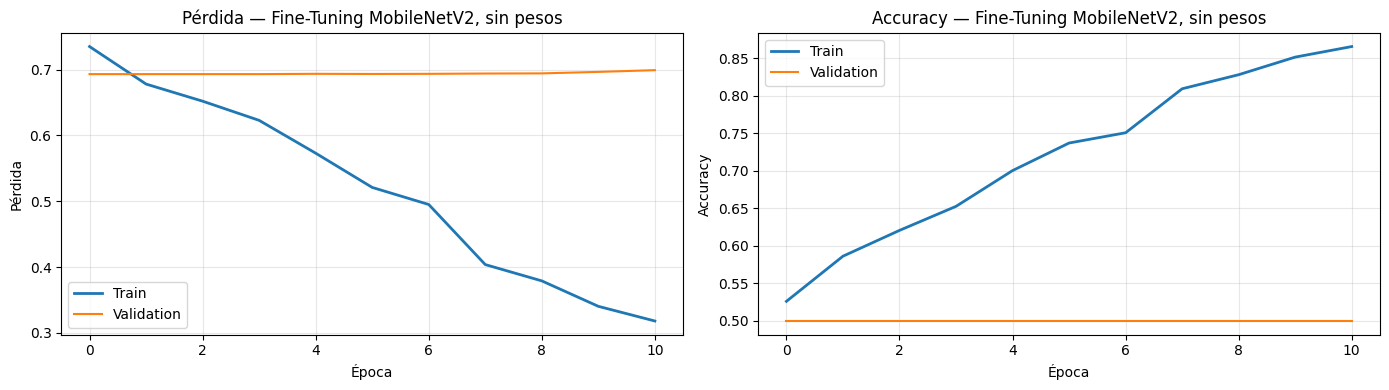

In [64]:
early_stop_ft = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)

history_ft = ft_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=32,
    epochs=50,
    callbacks=[early_stop_ft],
    verbose=1
)

plot_history(history_ft, title="Fine-Tuning MobileNetV2, sin pesos")

  Fine-Tuning MobileNetV2 sin pesos
  Test Loss:     0.6931
  Test Accuracy: 0.5000 (50.0%)

--- Classification Report ---
              precision    recall  f1-score   support

         cat       0.50      1.00      0.67       400
         dog       0.00      0.00      0.00       400

    accuracy                           0.50       800
   macro avg       0.25      0.50      0.33       800
weighted avg       0.25      0.50      0.33       800



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

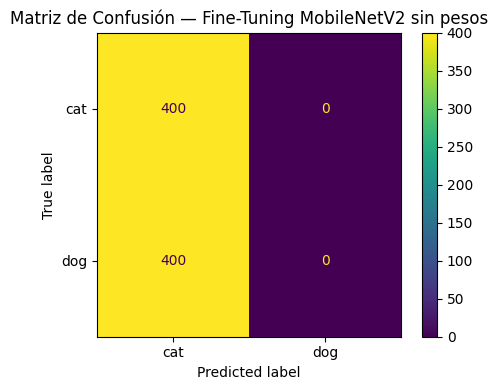

In [65]:
loss_ft, acc_ft = evaluate_model(ft_model, X_test, y_test, "Fine-Tuning MobileNetV2 sin pesos")

## Ejercicio 5

                         Modelo  Test Accuracy
          CNN Baseline (ad-hoc)        0.76000
Transfer Learning (MobileNetV2)        0.94375
      Fine-Tuning (MobileNetV2)        0.50000


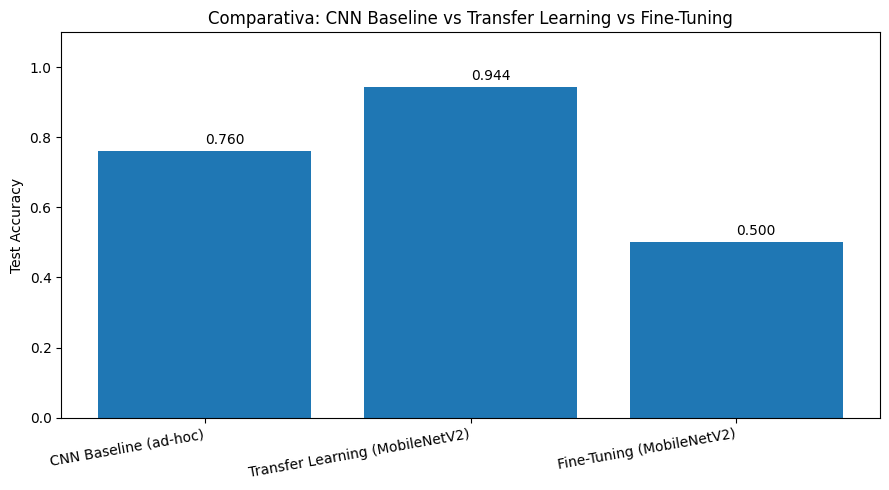

In [67]:
resultados = pd.DataFrame({
    'Modelo': ['CNN Baseline (ad-hoc)', 'Transfer Learning (MobileNetV2)', 'Fine-Tuning (MobileNetV2)'],
    'Test Accuracy': [acc_base, acc_tl, acc_ft]
})

print(resultados.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(resultados['Modelo'], resultados['Test Accuracy'])
ax.set_ylim(0, 1.1)
ax.set_ylabel('Test Accuracy')
ax.set_title('Comparativa: CNN Baseline vs Transfer Learning vs Fine-Tuning')
for bar, val in zip(bars, resultados['Test Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}',)
plt.xticks(rotation=10, ha='right')
plt.tight_layout()
plt.show()